# Sistema Predictivo de la Calidad del Aire en la Ciudad de Quito - Ecuador

<img src="airequito.jpg" style="display: block; margin: auto; width: 500px;">

## 1. INTRODUCCIÓN

## 1.1 Objetivos
- Aplicar los conocimientos adquiridos mediante los diversos cursos preparatorios para la maestría en Inteligencia Artificial Aplicada.
- Desarrollar un prototipo funcional utilizando herramientas de programación, ciencia de datos, aprendizaje automático, y bases de datos, considerando además los aspectos éticos y sociales del uso de la IA.
- Generar un modelo de ML que tenga la capacidad de predecir la concentración de PM2.5 de acuerdo a variables meteorológicas y factores urbanos como datos históricos de la ciudad de Quito - Ecuador.

## 1.2 Contexto y enfoque
La ciudad de Quito ha enfrentado durante años problemas de contaminación ambiental, principalmente asociados al tráfico vehicular. Esta situación ha motivado la implementación de políticas públicas como el “Pico y Placa”. En este contexto, se desarrolla un análisis exploratorio de datos, junto con la construcción de un modelo predictivo y una evaluación ética del uso de inteligencia artificial aplicada a este escenario.

Adicionalmente, con el objetivo de generar un modelo de aprendizaje automático para la predicción de la calidad del aire en la ciudad de Quito, se emplea un dataset proveniente de un estudio realizado entre 2023 y 2024, durante la crisis energética en Ecuador. Es importante destacar que estos datos resultan especialmente relevantes, ya que en dicho periodo se evidenció un notable deterioro en la calidad del aire, como consecuencia del uso de generadores eléctricos a diésel y del incremento del tráfico vehicular.

## 2. MODELO PREDICTIVO

## 2.1  Importación de librerías

In [2]:
import pandas as pd #Manipulación de datos en Python
import numpy as np #Cálculo numérico en Python
import matplotlib.pyplot as plt #Creación de graficos básicos
import seaborn as sns #Visualizaciones avanzadas

from sklearn.model_selection import train_test_split #Dividir datos de entrenamiento y prueba
from sklearn.linear_model import LinearRegression #Modelo de regresión lineal
from sklearn.ensemble import RandomForestRegressor #Modelo basado en árboles de decisión
from sklearn.metrics import mean_absolute_error, mean_squared_error #Métricas de evaluación

from xgboost import XGBRegressor #Modelo XGBoost

## 2.2 Lectura del dataset

In [3]:
df = pd.read_excel("Data_2023_2024_elCrisis.xlsx") #DataFrame - Almacenamiento de la información del dataset en una tabla
df.head() # Visualización de las primeras filas del dataset para inspeccionar el contenido

,date,average_daily_NO2 (ug/m3),average_daily_SO2 (ug/m3),average_daily_CO (mg/m3),average_daily_O3 (ug/m3),average_daily_PM2.5 (ug/m3),Cummulative_daily_rain (mm),average_daily_Temperature (C),average_daily_Solar Radiation (W/m2),average_daily_Wind Speed (m/s),average_daily_Relative Humidity (%)
0,2023-04-01,25.576446,3.057169,0.914096,24.756632,17.145885,1.4,14.727917,211.783333,1.279740,75.884688
1,2023-04-02,17.655305,2.289207,0.583659,24.721702,13.346875,7.8,15.270781,246.605469,1.272656,75.956354
2,2023-04-03,21.470120,2.481446,0.641910,20.866211,14.165208,61.3,14.734323,215.584948,1.299219,81.169375
3,2023-04-04,23.767019,3.169813,0.584882,18.831946,15.119206,44.3,14.319788,173.744868,1.138624,80.755714
4,2023-04-05,26.835455,5.250424,0.622304,21.042742,16.085573,108.1,14.302813,175.410781,1.274740,79.662135


## 2.3 Preprocesamiento y limpieza de la información

En este apartado es clave destacar que no se eliminarán directamente los valores nulos con la finalidad de evitar la pérdida de datos y, en consecuencia, no afectar significativamente el tamaño del dataset. Por lo tanto, para garantizar la calidad del entrenamiento del modelo, se optó por eliminar los registros que no cuenten con la variable objetivo (PM25) y aplicar una iterpolación para preservar la mayor cantidad de información posible.

In [4]:
df.columns = ["date", "NO2", "SO2", "CO", "O3",
              "PM25", "rain", "temperature",
              "solar_radiation", "wind_speed", "humidity"] #Reenombramiento de las columnas del dataframe para identificación
df['date'] = pd.to_datetime(df['date']) #Conversión de tipo: object (texto) a tipo: datetime (fecha real)
df.isnull().sum() #Verificación  de los valores NULOS existentes en cada columna del dataframe
df = df.dropna(subset=['PM25']) #Eliminación de valores NULOS si no existen datos en la variable objetivo
df.interpolate(inplace=True) #Rellenar los espacios NULOS con información de datos promedio (datos cercanos)

### 2.3.1 Feature Engineering

Se aplicó Feature Engineering con el objetivo de realizar una extracción de variables temporales para capturar patrones urbanos. Dicho de otra manera, se utilizaron características de la fecha, tales como el día de la semana, el mes y variables indicadoras como una política pública real de Quito que es el "pico y placa" para capturar patrones urbanos relacionados con la dinámica del tráfico y su impacto en la calidad del aire.

In [5]:
df['day_of_week'] = df['date'].dt.dayofweek #Mapeo del día de la semana - Conversión del día de la semana a un número del 0 al 6
df['month'] = df['date'].dt.month #Extracción del mes con números del 1 al 12
df['pico_placa'] = df['day_of_week'].apply(lambda x: 1 if x in [0,1,2,3,4] else 0) #Se crea una variable relacionada a la restricción vehicular

## 2.4 Análisis Exploratorio de Datos

Una vez tratados los datos, se procedió al análisis de la información que será utilizada en la generación del modelo predictivo. 

En primera instancia se estudió mediante visualización la evolución temporal que presenta el PM2.5 (Particulate Matter 2.5 - particulas microscópicas que se presentan en el aire con un diámetro inferior a 2.5 micrómetros) para identificar las tendencias y variaciones, así como la existenvia de posibles patrones en la calidad del aire.

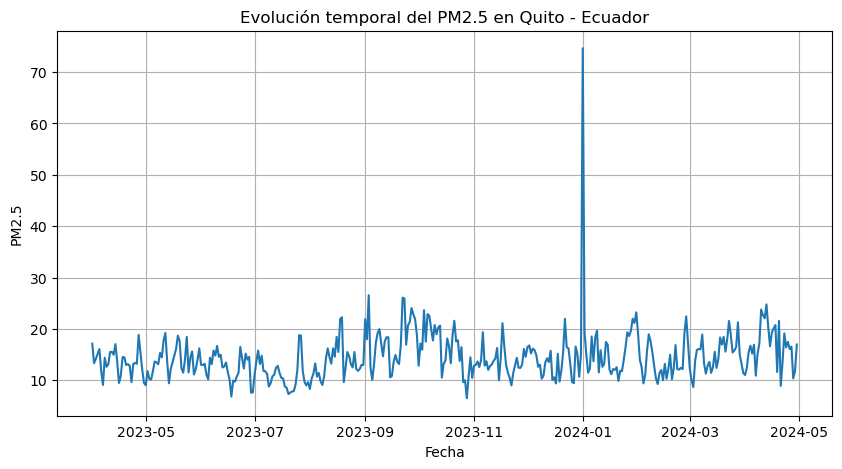

In [6]:
plt.figure(figsize=(10,5)) #Generación del lienzo para el gráfico (ancho = 10; alto = 5)
plt.plot(df['date'], df['PM25']) #Generación de una línea que sigue la información del dataframe
plt.title("Evolución temporal del PM2.5 en Quito - Ecuador") #Título del gráfico
plt.xlabel("Fecha") #Etiqueta del eje de coordenadas
plt.ylabel("PM2.5") #Etiqueta del eje de ordenadas
plt.grid() #Visualización de líneas guía
plt.show() #Impresión del gráfico contaminación VS tiempo

### 2.4.1 Correlación entre variables del dataframe

Esta sección se aplicó con la finalidad de que el mapa de calor de correlación nos permita verificar las variables fundamentales, es decir, identificar las relaciones que existen entre las variables de tal manera que se puedan destacar aquellas que tienen una mayor influenia sobre la concentración de PM2.5 en la calidad del aire. Esto es imoortante para mejorar las variables antes definidas y agregar aquellas que no fueron establecidas durante el proceso de Feature Engineering.

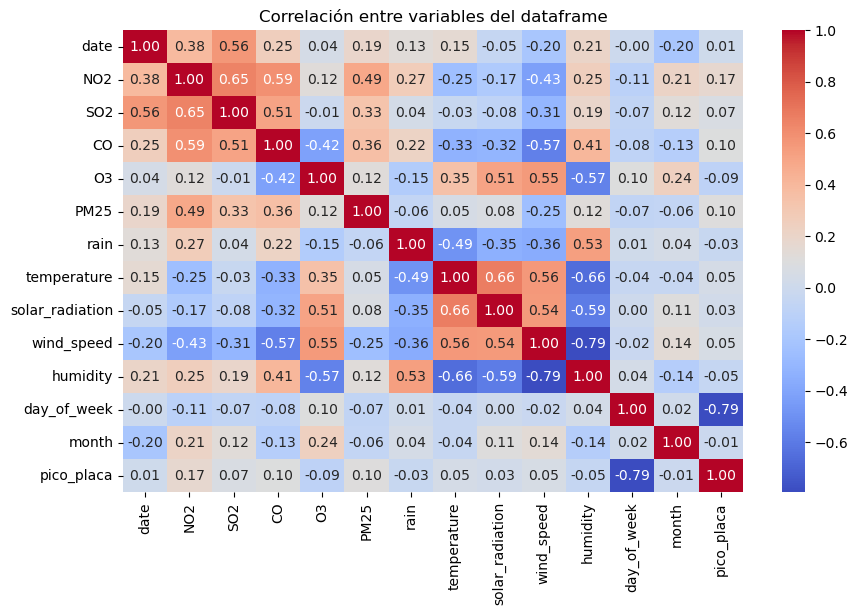

In [7]:
plt.figure(figsize=(10,6)) #Generación del lienzo para el gráfico (ancho = 10; alto = 6)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f") #Generación del mapa de calor con valores en el interior del gráfico para la correlación de las variables numéricas
plt.title("Correlación entre variables del dataframe") #Título del gráfico
plt.show() #Impresión del gráfico contaminación VS tiempo

A partir del gráfico se tienen los siguientes resultados:
- Se observa que existe una correlación positiva moderada entre la concentración de PM2.5 y los gases contaminantes tales como NO2, CO y SO2, lo cual establece que las emisiones de origen vehicular e industrial son factores fundamentales para la calidad del aire.
- Se verifica que las variables provenientes del clima tienen una baja correlación lineal con la concentración de PM2.5 y, por lo tanto, se sugiere que su influencia en la calidad del aire no se puede representar de manera lineal o es una característica secundaria.
- Se identifica que existen altas correlaciones entre variables climáticas, lo cual determina que existe una multicolinealidad que puede afectar a la estabilidad y la interpretación de los modelos lineales. Sin embargo, se pueden utilizar en modelos más avanzados.
- Se visualiza que el pico y placa, al estar basado en el día de la semana, presentan una alta correlación negativa dada la forma en la que fue definida la variable, pero presenta una baja correlación con la concentración de PM2.5, dando a entender que es débil, pero útil a nivel de contexto urbano.

### 2.4.2 Preparación de datos

En esta sección se dividen los datos en información de entrenamiento y prueba para los modelos a ser construidos y evaluados en los siguientes apartados.

In [8]:
X = df.drop(columns=['PM25', 'date']) #Creación de una matriz de variables independientes (features - todo lo que influye en la variable objetivo o target) o también conocido como entradas del modelo
y = df['PM25'] #Creación de la variable objetivo o target (lo que el modelo intentará aprender a predecir)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #División de los datos en dos conjuntos: 80% entrenamiento (X_train, y_train) y 20% prueba (X_test, y_test) con control de la aleatoriedad de la división

## 2.5 Modelos

### 2.5.1 Entrenamiento y predicción

En este apartado se tiene la implementación de tres modelos de regresión tales como: Regresión lineal, Random Forest y XGBoost. Esta sección tiene el objetivo de obtener una comparación en el desempeño de los modelos para predecir la concentración de PM2.5. Cabe destacar que cada uno de los modelos es entrenado con los datos generados en 2.4.2 y, posteriormente, evaluado sobre el conjunto de prueba.

In [9]:
# --- Creación de los modelos ---
lr = LinearRegression() #Configuración básica (sin parámetros) del modelo de Regresión Lineal
rf = RandomForestRegressor(n_estimators=100, random_state=42) #Configuración del modelo Random Forest utilizando 100 árboles de decisiones y controlando la aleatoriedad 
xgb = XGBRegressor(n_estimators=100) #Configuración del modelo XGBoost con 100 estimadores (árboles secuenciales)
# --- Entrenamiento de los modelos ---
# Cada modelo observa los datos de entrada (X_train) y aprende la relación con la salida o variable objetivo (y_train)
lr.fit(X_train, y_train) 
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
# --- Predicciones ---
# Cada modelo realiza las respectivas predicciones de la variable objetivo (Recibe datos nuevos almacenados en X_test y regresa los valores estimados)
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

### 2.5.2 Evaluación

Una vez que los datos han sido oportunamiente entrenados y nos reflejan un resultado de predicción, se desarrolló una función que permite evaluar el desempeños de los modelos, comparándolos mediante evaluaciones métricos con índices como MAE (Mean Absolute Error) y RMSE (Root Mean Squared Error). Esto con la finalidad de cuantificar el error en las predicciones y dar por seleccionado el modelo que mejor se ajustar a las condiciones reales.

In [10]:
def evaluar(nombre, y_test, y_pred): #Creación de una función reutilizable utilizando el nombre del modelo, valores reales y predicciones
    print(f"Modelo: {nombre}") #Muestra el modelo a ser evaluado
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}") #Muestra el error promedio generado al evaluar el modelo en cuestión
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}") #Muestra la raíz del error cuadrático medio del modelo que esta bajo evaluación
    print("-"*30) #Imprime guiones como un separador visual para ordenar los resultados

evaluar("Regresión Lineal", y_test, y_pred_lr) #Evaluación del modelo de Regresión Lineal
evaluar("Random Forest", y_test, y_pred_rf) #Evaluación del modelo Random Forest
evaluar("XGBoost", y_test, y_pred_xgb) #Evaluación del modelo XGBoost

Modelo: Regresión Lineal
MAE: 2.12
RMSE: 2.72
------------------------------
Modelo: Random Forest
MAE: 2.05
RMSE: 2.87
------------------------------
Modelo: XGBoost
MAE: 2.09
RMSE: 2.86
------------------------------


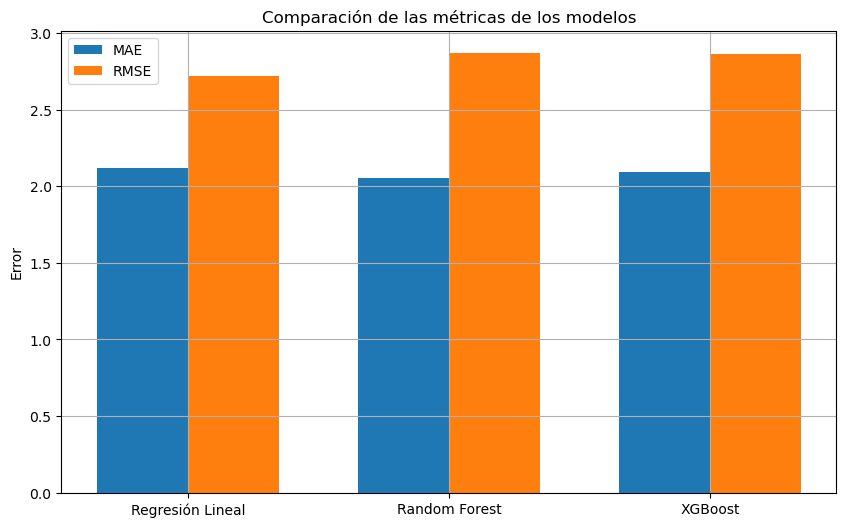

In [11]:
#--- Construcción de un gráfico de barras con los resultados de las métricas ---
modelos = ['Regresión Lineal', 'Random Forest', 'XGBoost']
mae = [2.12, 2.05, 2.09]
rmse = [2.72, 2.87, 2.86]
x = np.arange(len(modelos))
width = 0.35
plt.figure(figsize=(10,6))
plt.bar(x - width/2, mae, width, label='MAE')
plt.bar(x + width/2, rmse, width, label='RMSE')
plt.xticks(x, modelos)
plt.ylabel('Error')
plt.title('Comparación de las métricas de los modelos')
plt.legend()
plt.grid(True)
plt.show()

De acuerdo con los resultados obtenidos, se puede mencionar que el modelo correspondiente al Random Forest presentó un menor error promedio (MAE), lo cual establece que presenta, en general, una mejor precisión. Sin embargo, es preciso resaltar que el modelo basado en Regresión Lineal obtuvo un menor RMSE de tal manera que posee un mejor desempeño en la penalización de errores grandes y, por tanto, un manejo más adecuado de posibles valores atípicos. También es importante mencionar que el modelo XGBoost presentó un desempeño intermedio, es decir, es un modelo equilibrado, pero no dominante. 

Ahora bien, debido a que las diferencias entre los modelos son mínimas, se puede concluir que todos los modelos permiten predicir de manera considerablemente aceptable la concentración de PM2.5 en el aire de la ciudad de Quito. Estos modelos han presentado un desempeño similar, si bien Random Forest muestra una ligera ventaja en términos de error promedio, no existe una superioridad contundente, por lo que la elección del modelo podría depender de criterios adicionales como interpretabilidad, complejidad o costo computacional.

A continuación, se presenta un gráfico de puntos que permite verificar la información previamente analizada:

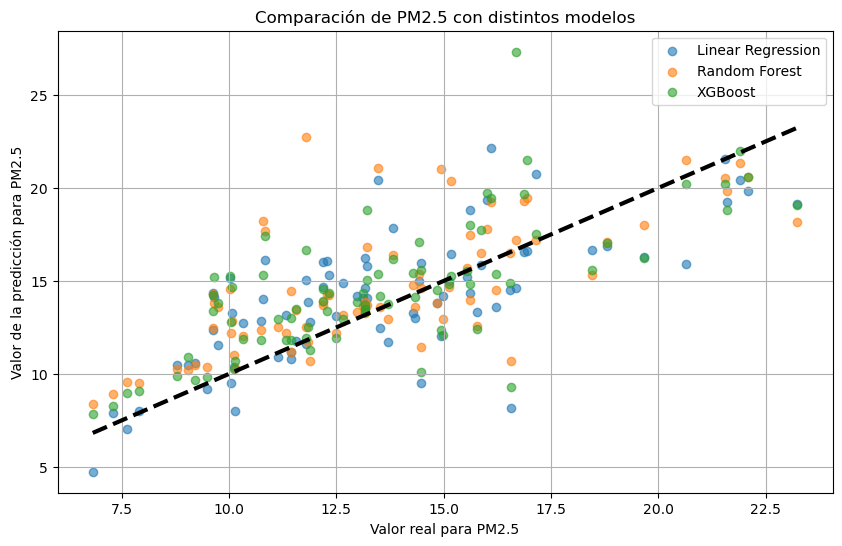

In [14]:
#--- Construcción de un gráfico de puntos para comparar las predicciones de los modelos ---
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_lr, label='Linear Regression', alpha=0.6)
plt.scatter(y_test, y_pred_rf, label='Random Forest', alpha=0.6)
plt.scatter(y_test, y_pred_xgb, label='XGBoost', alpha=0.6)
# --- Generación de una línea ideal (lugar en el que predicción es igual a valor real) ---
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=3)
plt.xlabel('Valor real para PM2.5')
plt.ylabel('Valor de la predicción para PM2.5')
plt.title('Comparación de PM2.5 con distintos modelos')
plt.legend()
plt.grid(True)
plt.show()

Cabe mencionar que el gráfico de puntos permite comprobar que los tres modelos tienen la capacidad de capturar de manera significativamente aceptable la tendencia general de los datos para la concentración de PM2.5. Sin embargo, es importante resaltar que existe una mayor dispersión en lo que respecta a los valores altos. 

# 3. INTERPRETACIÓN DE RESULTADOS

El análisis exploratorio que se llevó a cabo para el conjunto de datos permitió entender el comportamiento que tiene la concentración de PM2.5 en el aire de la ciudad de Quito, así como también la relación existente entre la variable objetivo y los distintos factores que se utilizaron en el caso de estudio.

En primera instancia, se logró verificar que la concentración de PM2.5 tiene una alta variabilidad dado que presenta valores atípicos que pueden estar asociados a eventos específicos de contaminación. Por lo tanto, es posible manifestar que la calidad del aire no es una variable constante puesto que fluctúa con respecto a múltiples factores ambientales y actividades humanas.

De igual manera, el análisis de las variables independientes arrojó la presencia de importantes patrones que contribuyen a la explicación del fenómeno en cuestión. Algunas variables mostraron una relación significativamente marcada con la variable objetivo, lo cual indica que tienen una alta incidencia en la generación del modelo. Sin embargo, también fue posible identificar ciertas variables con menor influencia, lo que puede sugerir la presencia de información redundante en el dataset.

Cabe destacar que se registraron posibles relaciones no lineales entre las variables de tal manera que se puede justificar el uso de modelos avanzados como el Random Forest y XGBoost. Esta interpretación es consistente con los resultados que se obtuvieron en la etapa de análisis, donde las correlaciones con la variable objetivo fueron débiles para varios factores.

Finalemente, el análisis gráfico determinó una alta dispersión en los valores de la concentración de PM2.5 conforme estos aumentan. Este comportamiento de datos establece que el fenómeno es más complejo de predecir cuando se tienen condiciones de alta contaminación, lo que representa un gran desafío para los modelos de predicción.
